In [1]:
import numpy as np
import matplotlib.pyplot as plt

def generate_training_data(
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):
    x = np.random.normal(0, 1, n)

    noise = np.random.normal(
        0,
        sigma,
        n
    )

    y = beta0 + beta1 * x + noise

    return x, y



In [2]:
def fit_linear_regression(x, y):

    x_mean = np.mean(x)
    y_mean = np.mean(y)

    Sxx = np.sum(
        (x - x_mean) ** 2
    )

    Sxy = np.sum(
        (x - x_mean) *
        (y - y_mean)
    )

    beta1_hat = Sxy / Sxx

    beta0_hat = (
        y_mean -
        beta1_hat * x_mean
    )

    return beta0_hat, beta1_hat

In [3]:
def predict(beta0_hat,beta1_hat,x_star):
    return(beta0_hat+beta1_hat*x_star)


In [4]:
def monte_carlo_predictive_distribution(
    x_star,
    R=5000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0
):

    predictions = []

    for _ in range(R):

       
        x_train, y_train = generate_training_data(
            n=n,
            beta0=beta0,
            beta1=beta1,
            sigma=sigma
        )

     

        beta0_hat, beta1_hat = fit_linear_regression(
            x_train,
            y_train
        )

      

        y_hat = predict(
            beta0_hat,
            beta1_hat,
            x_star
        )

       
        future_noise = np.random.normal(
            0,
            sigma
        )

       

        y_star = y_hat + future_noise

        predictions.append(y_star)

    return np.array(predictions)

def monte_carlo_prediction_interval(x_star,confidence=0.95,R=5000,n=50,beta0=1.0,beta1=2.0,sigma=1.0):
    samples = monte_carlo_predictive_distribution(
        x_star=x_star,
        R=R,
        n=n,
        beta0=beta0,
        beta1=beta1,
        sigma=sigma
    )

    alpha = 1 - confidence

    lower = np.quantile(
        samples,
        alpha / 2
    )

    upper = np.quantile(
        samples,
        1 - alpha / 2
    )

    median = np.quantile(
        samples,
        0.5
    )

    return lower, median, upper, samples

np.random.seed(42)

lower, median, upper, samples = (
    monte_carlo_prediction_interval(
        x_star=1.0,
        confidence=0.95,
        R=5000
    )
)

print("Median prediction:", median)
print("95% PI:", (lower, upper))

Median prediction: 2.9939620579830977
95% PI: (np.float64(0.9379697988121196), np.float64(4.970042216511043))


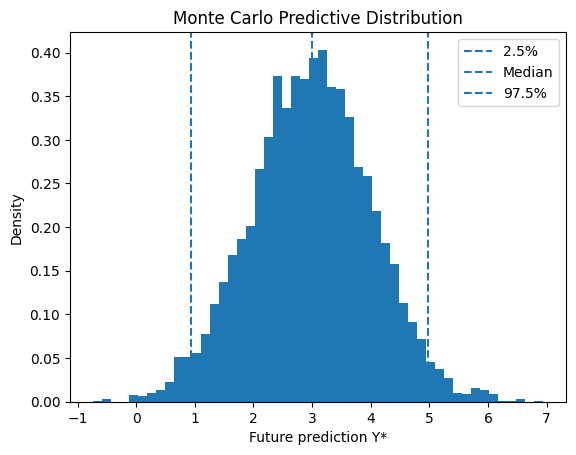

In [5]:
plt.hist(
    samples,
    bins=50,
    density=True
)

plt.axvline(
    lower,
    linestyle="--",
    label="2.5%"
)

plt.axvline(
    median,
    linestyle="--",
    label="Median"
)

plt.axvline(
    upper,
    linestyle="--",
    label="97.5%"
)

plt.xlabel("Future prediction Y*")
plt.ylabel("Density")
plt.title("Monte Carlo Predictive Distribution")
plt.legend()

plt.show()

In [6]:
def coverage_test(
    num_experiments=1000,
    confidence=0.95,
    R=1000,
    n=50,
    beta0=1.0,
    beta1=2.0,
    sigma=1.0,
    x_star=1.0
):

    covered = 0

    for _ in range(num_experiments):

        # -------------------------
        # Construct MC prediction interval
        # -------------------------

        lower, median, upper, _ = (
            monte_carlo_prediction_interval(
                x_star=x_star,
                confidence=confidence,
                R=R,
                n=n,
                beta0=beta0,
                beta1=beta1,
                sigma=sigma
            )
        )

        # -------------------------
        # Generate TRUE future observation
        # -------------------------

        true_mean = (
            beta0 +
            beta1 * x_star
        )

        y_star = (
            true_mean +
            np.random.normal(
                0,
                sigma
            )
        )

        # -------------------------
        # Coverage test
        # -------------------------

        if lower <= y_star <= upper:
            covered += 1

    empirical_coverage = (
        covered / num_experiments
    )

    return empirical_coverage

In [7]:
coverage = coverage_test(
    num_experiments=1000,
    confidence=0.95,
    R=1000
)

empirical=[]

print(
    "Empirical coverage:",
    coverage
)
levels = [
    0.80,
    0.90,
    0.95,
    0.99
]

for confidence in levels:

    coverage = coverage_test(
        num_experiments=1000,
        confidence=confidence,
        R=1000
    )
    empirical.append(coverage)
    print(
        f"Nominal={confidence:.2f}, "
        f"Empirical={coverage:.4f}"
    )

Empirical coverage: 0.954


Nominal=0.80, Empirical=0.7980


Nominal=0.90, Empirical=0.9050


Nominal=0.95, Empirical=0.9580


Nominal=0.99, Empirical=0.9860


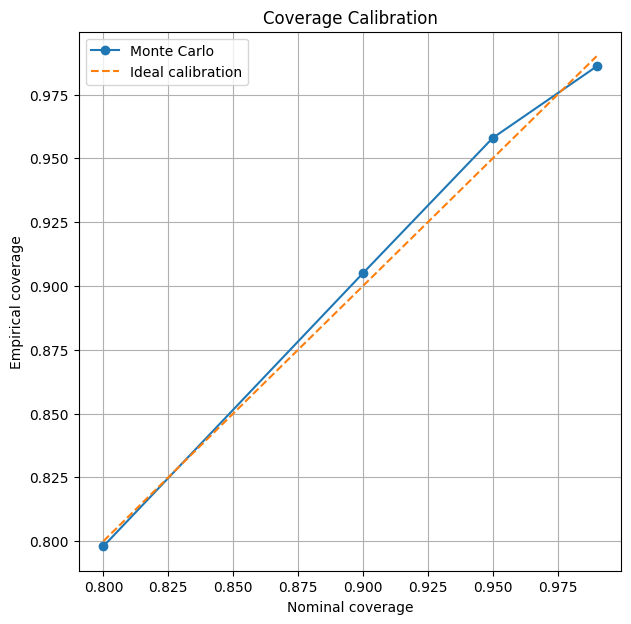

In [8]:
plt.figure(figsize=(7,7))
plt.plot(
    levels,
    empirical,
    marker="o",
    label="Monte Carlo"
)

plt.plot(
    levels,
    levels,
    linestyle="--",
    label="Ideal calibration"
)
plt.xlabel("Nominal coverage")
plt.ylabel("Empirical coverage")

plt.title("Coverage Calibration")
plt.legend()
plt.grid(True)

plt.show()

---
## Part 2 — Bayesian Linear Regression + Chernoff-Bound Intervals

Everything above uses **Monte Carlo** simulation over the OLS estimator to
build prediction intervals. This section adds two more ways to get an
interval, and proves the bound behind one of them:

1. **Closed-form OLS interval** — same target as the Monte Carlo PI above,
   but via the exact formula instead of simulation (sanity check).
2. **Bayesian conjugate posterior interval** — puts a Gaussian prior on
   `(beta0, beta1)`, computes the exact posterior, and uses the posterior
   predictive distribution.
3. **Chernoff-bound interval** — for both (1) and (2), a bound derived from
   the moment generating function rather than the exact Gaussian quantile.
   It's provably valid under a *weaker* assumption (sub-Gaussian noise, not
   exact normality), at the cost of being wider.

**Important conditioning note (relates to "Known Issue 2" above):** the cells
below fix `x_train` once, then resample only the noise/`y_train`. That's the
standard conditional target (`E[y|x_star]` and `y*` given a fixed design),
which is what the closed-form and Bayesian formulas below assume. Comparing
them against the *unconditional* Monte Carlo loop above without fixing
`x_train` would be an apples-to-oranges comparison.


### Proof: the Chernoff bound used below

**Chernoff's technique.** For any random variable $Z$ and $t>0$, Markov's
inequality applied to $e^{\lambda Z}$ gives, for every $\lambda > 0$,

$$P(Z \ge t) = P(e^{\lambda Z} \ge e^{\lambda t}) \le \frac{\mathbb E[e^{\lambda Z}]}{e^{\lambda t}}.$$

Minimizing the right-hand side over $\lambda>0$ gives the Chernoff bound
$P(Z\ge t) \le \exp\big(-\sup_{\lambda>0}[\lambda t - \log \mathbb E e^{\lambda Z}]\big)$.

**Applied to a centered Gaussian.** Let $Z \sim \mathcal N(0,v)$. Its MGF is
$\mathbb E[e^{\lambda Z}] = \exp(\lambda^2 v/2)$, so

$$P(Z\ge t) \le \exp\Big(\lambda^2 v/2 - \lambda t\Big) \quad \text{for all } \lambda>0.$$

The right side is minimized at $\lambda^\star = t/v$, giving

$$P(Z\ge t) \le \exp\!\left(-\frac{t^2}{2v}\right).$$

By symmetry ($-Z$ is also $\mathcal N(0,v)$) and a union bound over the two
tails,

$$P(|Z|\ge t) \le 2\exp\!\left(-\frac{t^2}{2v}\right). \qquad (\star)$$

Note this derivation only used $Z$'s MGF, not that it's exactly Gaussian —
$(\star)$ holds for **any** mean-zero $v$-sub-Gaussian $Z$, e.g. bounded or
otherwise well-behaved non-Gaussian noise, not just $\mathcal N(0,v)$.

**Applying $(\star)$ to prediction error.**

*OLS case.* With $X$ fixed and $\varepsilon \sim \mathcal N(0,\sigma^2 I)$,
$\hat\beta = (X^\top X)^{-1}X^\top y = \beta + (X^\top X)^{-1}X^\top\varepsilon$,
so $\hat\beta-\beta \sim \mathcal N(0,\ \sigma^2 (X^\top X)^{-1})$. The
prediction error at $x_*$ is
$Z = y_* - \hat y_* = x_*^\top(\beta-\hat\beta) + \varepsilon_*$, a sum of two
independent centered Gaussians, so $Z\sim\mathcal N(0, v)$ with
$v = \sigma^2\big(1 + x_*^\top (X^\top X)^{-1} x_*\big)$ — exactly the
classical prediction-interval variance quoted in the README. Plugging this
$v$ into $(\star)$ gives $t(\delta) = \sqrt{2v\log(2/\delta)}$ as a
$(1-\delta)$-valid interval half-width.

*Bayesian case.* The posterior predictive is
$y_* - x_*^\top\beta_n \sim \mathcal N(0,\ v)$ with
$v = x_*^\top \Sigma_n x_* + \sigma^2$ (see Part 1 derivation). Same $(\star)$
argument, same closed form for $t(\delta)$.

In both cases the exact Gaussian quantile $z_{\delta/2}\sqrt v$ is *tighter*
than the Chernoff width $\sqrt{2v\log(2/\delta)}$ — Chernoff is what you fall
back on when you're only willing to assume sub-Gaussianity, not exact
normality. The coverage test below shows this concretely: the Chernoff
interval over-covers relative to its nominal level, the exact interval
tracks it.


In [9]:
from scipy import stats

# ---- OLS: closed-form conditional interval, matching the classical formula
def ols_fit(x, y):
    X = np.column_stack([np.ones_like(x), x])
    XtX_inv = np.linalg.inv(X.T @ X)
    beta_hat = XtX_inv @ X.T @ y
    return beta_hat, XtX_inv

def ols_exact_interval(x_train, y_train, x_star, confidence, sigma=1.0):
    beta_hat, XtX_inv = ols_fit(x_train, y_train)
    xs = np.array([1.0, x_star])
    y_hat = xs @ beta_hat
    v = sigma**2 * (1 + xs @ XtX_inv @ xs)
    delta = 1 - confidence
    z = stats.norm.ppf(1 - delta / 2)
    hw = z * np.sqrt(v)
    return y_hat - hw, y_hat + hw

def ols_chernoff_interval(x_train, y_train, x_star, confidence, sigma=1.0):
    beta_hat, XtX_inv = ols_fit(x_train, y_train)
    xs = np.array([1.0, x_star])
    y_hat = xs @ beta_hat
    v = sigma**2 * (1 + xs @ XtX_inv @ xs)
    delta = 1 - confidence
    t = np.sqrt(2 * v * np.log(2 / delta))
    return y_hat - t, y_hat + t


# ---- Bayesian conjugate posterior (known sigma^2), Gaussian prior N(0, prior_scale*I)
def bayes_fit(x, y, sigma2=1.0, prior_scale=10.0):
    X = np.column_stack([np.ones_like(x), x])
    p = X.shape[1]
    Sigma0_inv = np.eye(p) / prior_scale
    Sigma_n_inv = Sigma0_inv + (X.T @ X) / sigma2
    Sigma_n = np.linalg.inv(Sigma_n_inv)
    beta_n = Sigma_n @ ((X.T @ y) / sigma2)
    return beta_n, Sigma_n

def bayes_exact_interval(x_train, y_train, x_star, confidence, sigma2=1.0):
    beta_n, Sigma_n = bayes_fit(x_train, y_train, sigma2)
    xs = np.array([1.0, x_star])
    mean = xs @ beta_n
    var = xs @ Sigma_n @ xs + sigma2
    delta = 1 - confidence
    z = stats.norm.ppf(1 - delta / 2)
    hw = z * np.sqrt(var)
    return mean - hw, mean + hw

def bayes_chernoff_interval(x_train, y_train, x_star, confidence, sigma2=1.0):
    beta_n, Sigma_n = bayes_fit(x_train, y_train, sigma2)
    xs = np.array([1.0, x_star])
    mean = xs @ beta_n
    var = xs @ Sigma_n @ xs + sigma2
    delta = 1 - confidence
    t = np.sqrt(2 * var * np.log(2 / delta))
    return mean - t, mean + t


In [10]:
def coverage_test_conditional(x_train, methods, num_experiments=2000, confidence=0.95,
                               beta0=1.0, beta1=2.0, sigma=1.0, x_star=1.0):
    n = len(x_train)
    results = {name: 0 for name in methods}
    for _ in range(num_experiments):
        noise = np.random.normal(0, sigma, n)
        y_train = beta0 + beta1 * x_train + noise
        true_mean = beta0 + beta1 * x_star
        y_star = true_mean + np.random.normal(0, sigma)
        for name, fn in methods.items():
            lo, hi = fn(x_train, y_train, x_star, confidence)
            if lo <= y_star <= hi:
                results[name] += 1
    return {name: c / num_experiments for name, c in results.items()}

np.random.seed(42)
x_train_fixed = np.random.normal(0, 1, 50)  # fixed design, per README's suggested fix

methods = {
    "OLS exact":      ols_exact_interval,
    "OLS Chernoff":   ols_chernoff_interval,
    "Bayes exact":     bayes_exact_interval,
    "Bayes Chernoff": bayes_chernoff_interval,
}

levels = [0.80, 0.90, 0.95, 0.99]
coverage_table = {name: [] for name in methods}

for conf in levels:
    cov = coverage_test_conditional(x_train_fixed, methods, num_experiments=2000, confidence=conf)
    for name in methods:
        coverage_table[name].append(cov[name])
    print(f"nominal={conf:.2f}  " + "  ".join(f"{k}={v:.3f}" for k, v in cov.items()))


nominal=0.80  OLS exact=0.794  OLS Chernoff=0.969  Bayes exact=0.796  Bayes Chernoff=0.969


nominal=0.90  OLS exact=0.891  OLS Chernoff=0.979  Bayes exact=0.889  Bayes Chernoff=0.979


nominal=0.95  OLS exact=0.946  OLS Chernoff=0.992  Bayes exact=0.947  Bayes Chernoff=0.991


nominal=0.99  OLS exact=0.987  OLS Chernoff=0.999  Bayes exact=0.988  Bayes Chernoff=0.999


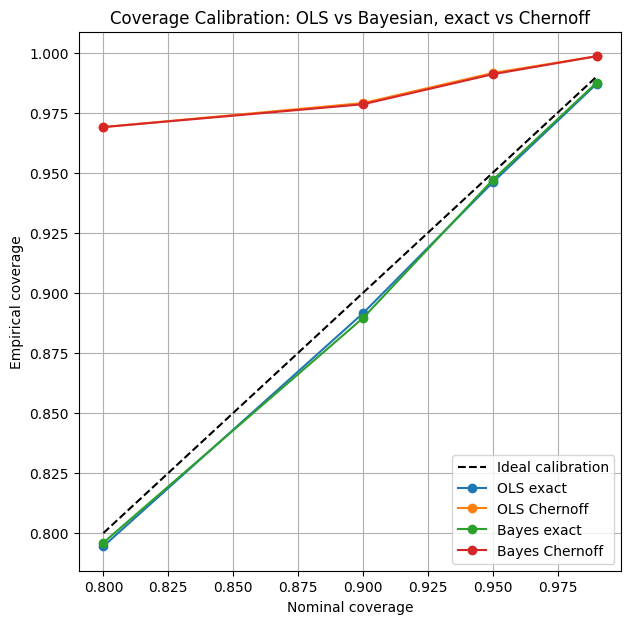

In [11]:
plt.figure(figsize=(7, 7))
plt.plot(levels, levels, linestyle="--", color="black", label="Ideal calibration")
for name, vals in coverage_table.items():
    plt.plot(levels, vals, marker="o", label=name)

plt.xlabel("Nominal coverage")
plt.ylabel("Empirical coverage")
plt.title("Coverage Calibration: OLS vs Bayesian, exact vs Chernoff")
plt.legend()
plt.grid(True)
plt.show()
